In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs('../reports/charts', exist_ok=True)

print("Libraries loaded!")

Libraries loaded!


In [4]:
# Load data
nav = pd.read_csv('../data/processed/02_nav_history_clean.csv', parse_dates=['date'])
funds = pd.read_csv('../data/processed/01_fund_master_clean.csv')
benchmark = pd.read_csv('../data/processed/10_benchmark_indices_clean.csv', parse_dates=['date'])

print("NAV:", nav.shape)
print("Funds:", funds.shape)
print("Benchmark:", benchmark.shape)
print("\nBenchmark indices available:")
print(benchmark['index_name'].unique())

NAV: (64320, 3)
Funds: (40, 15)
Benchmark: (8050, 3)

Benchmark indices available:
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [5]:
# Task 1 — Compute Daily Returns

# Sort by fund and date
nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)

# Calculate daily return for each fund
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Validate — check distribution looks reasonable
print("Daily return statistics:")
print(nav['daily_return'].describe())
print("\nAny extreme values (>20% daily move):", (nav['daily_return'].abs() > 0.20).sum())
print("Missing returns (first row of each fund):", nav['daily_return'].isnull().sum())

Daily return statistics:
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

Any extreme values (>20% daily move): 0
Missing returns (first row of each fund): 40


In [6]:
# Task 2 — Compute CAGR

def compute_cagr(nav_series, years):
    """Calculate CAGR over a given number of years"""
    days = int(years * 365)
    if len(nav_series) < days:
        return np.nan
    nav_end = nav_series.iloc[-1]
    nav_start = nav_series.iloc[-days]
    return (nav_end / nav_start) ** (1/years) - 1

# Calculate CAGR for each fund
cagr_results = []

for code in nav['amfi_code'].unique():
    fund_nav = nav[nav['amfi_code'] == code].sort_values('date')['nav']
    
    cagr_results.append({
        'amfi_code': code,
        'cagr_1yr': compute_cagr(fund_nav, 1),
        'cagr_3yr': compute_cagr(fund_nav, 3),
        'cagr_5yr': compute_cagr(fund_nav, 5) if len(fund_nav) >= 365*5 else np.nan
    })

df_cagr = pd.DataFrame(cagr_results)

# Merge with fund names
df_cagr = df_cagr.merge(funds[['amfi_code', 'scheme_name', 'category']], on='amfi_code')

# Convert to percentages
df_cagr['cagr_1yr_pct'] = (df_cagr['cagr_1yr'] * 100).round(2)
df_cagr['cagr_3yr_pct'] = (df_cagr['cagr_3yr'] * 100).round(2)
df_cagr['cagr_5yr_pct'] = (df_cagr['cagr_5yr'] * 100).round(2)

print("CAGR Results:")
print(df_cagr[['scheme_name', 'cagr_1yr_pct', 'cagr_3yr_pct', 'cagr_5yr_pct']].sort_values('cagr_3yr_pct', ascending=False).head(10))

CAGR Results:
                                          scheme_name  cagr_1yr_pct  \
16                Axis Midcap Fund - Regular - Growth         22.85   
34      Mirae Asset Large Cap Fund - Regular - Growth         19.48   
24          ICICI Pru Bluechip Fund - Direct - Growth         13.37   
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...         53.41   
25           ICICI Pru Midcap Fund - Regular - Growth         30.37   
19          SBI Bluechip Fund - Regular Plan - Growth         58.79   
30             Kotak Flexicap Fund - Regular - Growth         26.93   
3       ABSL Frontline Equity Fund - Regular - Growth         48.43   
36      Mirae Asset Tax Saver Fund - Regular - Growth         40.29   
39              DSP Small Cap Fund - Regular - Growth         64.88   

    cagr_3yr_pct  cagr_5yr_pct  
16         36.21           NaN  
34         33.95           NaN  
24         32.70           NaN  
2          32.37           NaN  
25         31.22           NaN  
19    

In [7]:
# Task 3 & 4 — Sharpe and Sortino Ratios

Rf = 0.065 / 252  # Risk-free rate (6.5% annual RBI repo rate, converted to daily)

sharpe_results = []

for code in nav['amfi_code'].unique():
    fund_returns = nav[nav['amfi_code'] == code]['daily_return'].dropna()
    
    # Sharpe Ratio
    excess_returns = fund_returns - Rf
    sharpe = (excess_returns.mean() / fund_returns.std()) * np.sqrt(252)
    
    # Sortino Ratio — only downside volatility
    downside_returns = fund_returns[fund_returns < 0]
    downside_std = downside_returns.std()
    sortino = (excess_returns.mean() / downside_std) * np.sqrt(252)
    
    sharpe_results.append({
        'amfi_code': code,
        'sharpe_ratio': round(sharpe, 3),
        'sortino_ratio': round(sortino, 3)
    })

df_sharpe = pd.DataFrame(sharpe_results)
df_sharpe = df_sharpe.merge(funds[['amfi_code', 'scheme_name', 'category']], on='amfi_code')

print("Top 10 funds by Sharpe Ratio:")
print(df_sharpe[['scheme_name', 'sharpe_ratio', 'sortino_ratio']].sort_values('sharpe_ratio', ascending=False).head(10))

Top 10 funds by Sharpe Ratio:
                                          scheme_name  sharpe_ratio  \
34      Mirae Asset Large Cap Fund - Regular - Growth         1.068   
30             Kotak Flexicap Fund - Regular - Growth         0.966   
36      Mirae Asset Tax Saver Fund - Regular - Growth         0.919   
25           ICICI Pru Midcap Fund - Regular - Growth         0.883   
19          SBI Bluechip Fund - Regular Plan - Growth         0.861   
38                 DSP Midcap Fund - Regular - Growth         0.833   
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...         0.808   
9      Nippon India Large Cap Fund - Regular - Growth         0.759   
16                Axis Midcap Fund - Regular - Growth         0.731   
3       ABSL Frontline Equity Fund - Regular - Growth         0.717   

    sortino_ratio  
34          1.491  
30          1.480  
36          1.353  
25          1.286  
19          1.291  
38          1.168  
2           1.144  
9           1.099  
16      

In [8]:
# Task 5 — Alpha and Beta vs Nifty 100

# Get Nifty 100 daily returns
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'].sort_values('date').copy()
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna()

alpha_beta_results = []

for code in nav['amfi_code'].unique():
    fund_data = nav[nav['amfi_code'] == code][['date', 'daily_return']].dropna()
    
    # Merge fund returns with benchmark returns on date
    merged = fund_data.merge(nifty100[['date', 'benchmark_return']], on='date', how='inner')
    
    if len(merged) < 30:
        continue
    
    # OLS regression — fund return = alpha + beta * benchmark_return
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['benchmark_return'], merged['daily_return']
    )
    
    alpha_beta_results.append({
        'amfi_code': code,
        'alpha': round(intercept * 252, 4),  # annualise alpha
        'beta': round(slope, 4),
        'r_squared': round(r_value**2, 4)
    })

df_alpha_beta = pd.DataFrame(alpha_beta_results)
df_alpha_beta = df_alpha_beta.merge(funds[['amfi_code', 'scheme_name', 'category']], on='amfi_code')

print("Alpha & Beta Results:")
print(df_alpha_beta[['scheme_name', 'alpha', 'beta', 'r_squared']].sort_values('alpha', ascending=False).head(10))

Alpha & Beta Results:
                                          scheme_name   alpha    beta  \
21         SBI Small Cap Fund - Regular Plan - Growth  0.3034 -0.0232   
39              DSP Small Cap Fund - Regular - Growth  0.3006  0.0115   
25           ICICI Pru Midcap Fund - Regular - Growth  0.2926  0.0005   
36      Mirae Asset Tax Saver Fund - Regular - Growth  0.2827  0.0181   
30             Kotak Flexicap Fund - Regular - Growth  0.2733 -0.0228   
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.2720  0.0051   
34      Mirae Asset Large Cap Fund - Regular - Growth  0.2698  0.0237   
38                 DSP Midcap Fund - Regular - Growth  0.2660 -0.0025   
16                Axis Midcap Fund - Regular - Growth  0.2608 -0.0663   
19          SBI Bluechip Fund - Regular Plan - Growth  0.2320 -0.0318   

    r_squared  
21     0.0001  
39     0.0000  
25     0.0000  
36     0.0002  
30     0.0003  
2      0.0000  
34     0.0005  
38     0.0000  
16     0.0019  
19     0.0009 

In [9]:
# Task 6 — Maximum Drawdown

drawdown_results = []

for code in nav['amfi_code'].unique():
    fund_nav = nav[nav['amfi_code'] == code].sort_values('date')
    
    # Calculate running maximum
    fund_nav = fund_nav.copy()
    fund_nav['running_max'] = fund_nav['nav'].cummax()
    
    # Drawdown = current NAV / running max - 1 (negative value)
    fund_nav['drawdown'] = fund_nav['nav'] / fund_nav['running_max'] - 1
    
    # Maximum drawdown = worst (most negative) drawdown
    max_dd = fund_nav['drawdown'].min()
    worst_date = fund_nav.loc[fund_nav['drawdown'].idxmin(), 'date']
    
    drawdown_results.append({
        'amfi_code': code,
        'max_drawdown_pct': round(max_dd * 100, 2),
        'worst_date': worst_date
    })

df_drawdown = pd.DataFrame(drawdown_results)
df_drawdown = df_drawdown.merge(funds[['amfi_code', 'scheme_name', 'category']], on='amfi_code')

print("Worst Maximum Drawdowns:")
print(df_drawdown[['scheme_name', 'max_drawdown_pct', 'worst_date']].sort_values('max_drawdown_pct').head(10))

Worst Maximum Drawdowns:
                                       scheme_name  max_drawdown_pct  \
22       SBI Small Cap Fund - Direct Plan - Growth            -52.57   
17          Axis Small Cap Fund - Regular - Growth            -51.68   
4           ABSL Small Cap Fund - Regular - Growth            -35.45   
39           DSP Small Cap Fund - Regular - Growth            -31.17   
21      SBI Small Cap Fund - Regular Plan - Growth            -28.71   
7              UTI Mid Cap Fund - Regular - Growth            -28.00   
0        HDFC Top 100 Fund - Regular Plan - Growth            -24.73   
29   Kotak Emerging Equity Fund - Regular - Growth            -24.00   
11  Nippon India Small Cap Fund - Regular - Growth            -23.34   
15            Axis Bluechip Fund - Direct - Growth            -21.75   

   worst_date  
22 2025-10-28  
17 2026-05-11  
4  2026-05-11  
39 2025-01-03  
21 2025-05-14  
7  2026-04-27  
0  2022-09-15  
29 2024-10-17  
11 2026-02-20  
15 2023-05-22  


In [10]:
# Task 7 — Fund Scorecard (0-100)

# Merge all metrics
scorecard = df_cagr[['amfi_code', 'scheme_name', 'category', 'cagr_3yr_pct']].copy()
scorecard = scorecard.merge(df_sharpe[['amfi_code', 'sharpe_ratio']], on='amfi_code')
scorecard = scorecard.merge(df_alpha_beta[['amfi_code', 'alpha']], on='amfi_code')
scorecard = scorecard.merge(df_drawdown[['amfi_code', 'max_drawdown_pct']], on='amfi_code')
scorecard = scorecard.merge(funds[['amfi_code', 'expense_ratio_pct']], on='amfi_code')

# Rank each metric (higher rank = better)
scorecard['cagr_rank'] = scorecard['cagr_3yr_pct'].rank(ascending=True)
scorecard['sharpe_rank'] = scorecard['sharpe_ratio'].rank(ascending=True)
scorecard['alpha_rank'] = scorecard['alpha'].rank(ascending=True)
scorecard['expense_rank'] = scorecard['expense_ratio_pct'].rank(ascending=False)  # lower is better
scorecard['drawdown_rank'] = scorecard['max_drawdown_pct'].rank(ascending=False)  # less negative is better

# Composite score — 30% CAGR + 25% Sharpe + 20% Alpha + 15% Expense + 10% Drawdown
total_funds = len(scorecard)
scorecard['score'] = (
    0.30 * (scorecard['cagr_rank'] / total_funds * 100) +
    0.25 * (scorecard['sharpe_rank'] / total_funds * 100) +
    0.20 * (scorecard['alpha_rank'] / total_funds * 100) +
    0.15 * (scorecard['expense_rank'] / total_funds * 100) +
    0.10 * (scorecard['drawdown_rank'] / total_funds * 100)
)
scorecard['score'] = scorecard['score'].round(1)

print("TOP 10 FUNDS BY SCORECARD:")
print(scorecard[['scheme_name', 'score', 'cagr_3yr_pct', 'sharpe_ratio']].sort_values('score', ascending=False).head(10))

# Save
scorecard.to_csv('../data/processed/fund_scorecard.csv', index=False)
print("\n✅ Saved fund_scorecard.csv")

TOP 10 FUNDS BY SCORECARD:
                                          scheme_name  score  cagr_3yr_pct  \
25           ICICI Pru Midcap Fund - Regular - Growth   85.1         31.22   
16                Axis Midcap Fund - Regular - Growth   82.0         36.21   
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...   80.5         32.37   
34      Mirae Asset Large Cap Fund - Regular - Growth   80.0         33.95   
30             Kotak Flexicap Fund - Regular - Growth   78.2         29.69   
21         SBI Small Cap Fund - Regular Plan - Growth   76.1         26.85   
39              DSP Small Cap Fund - Regular - Growth   75.6         27.15   
24          ICICI Pru Bluechip Fund - Direct - Growth   75.1         32.70   
36      Mirae Asset Tax Saver Fund - Regular - Growth   73.2         28.48   
19          SBI Bluechip Fund - Regular Plan - Growth   72.4         30.32   

    sharpe_ratio  
25         0.883  
16         0.731  
2          0.808  
34         1.068  
30         0.966  


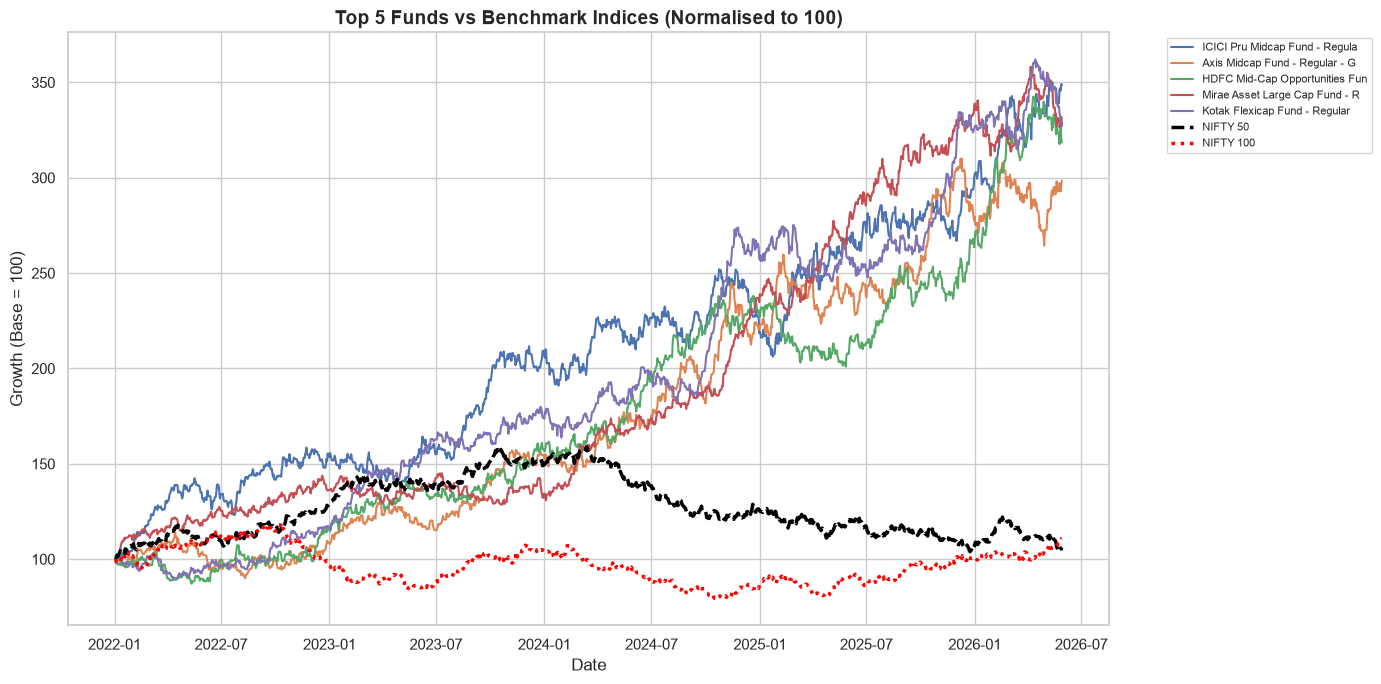

✅ Chart saved!


In [11]:
# Task 8 — Benchmark Comparison Chart

# Get top 5 funds by scorecard
top5_codes = scorecard.sort_values('score', ascending=False).head(5)['amfi_code'].tolist()
top5_names = scorecard.sort_values('score', ascending=False).head(5).set_index('amfi_code')['scheme_name'].to_dict()

# Get their NAV data
nav_top5 = nav[nav['amfi_code'].isin(top5_codes)].copy()

# Get Nifty 50 and Nifty 100 benchmark data
nifty50 = benchmark[benchmark['index_name'] == 'NIFTY50'].sort_values('date').copy()
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'].sort_values('date').copy()

# Normalise everything to 100 at start date
start_date = nav_top5['date'].min()

def normalise(series):
    return series / series.iloc[0] * 100

plt.figure(figsize=(14, 7))

# Plot top 5 funds
for code in top5_codes:
    fund_data = nav_top5[nav_top5['amfi_code'] == code].sort_values('date')
    name = top5_names[code][:30]
    plt.plot(fund_data['date'], normalise(fund_data['nav'].reset_index(drop=True)), 
             linewidth=1.5, label=name)

# Plot benchmarks
nifty50_filtered = nifty50[nifty50['date'] >= start_date]
nifty100_filtered = nifty100[nifty100['date'] >= start_date]

plt.plot(nifty50_filtered['date'], 
         normalise(nifty50_filtered['close_value'].reset_index(drop=True)),
         linewidth=2.5, linestyle='--', color='black', label='NIFTY 50')
plt.plot(nifty100_filtered['date'], 
         normalise(nifty100_filtered['close_value'].reset_index(drop=True)),
         linewidth=2.5, linestyle=':', color='red', label='NIFTY 100')

plt.title('Top 5 Funds vs Benchmark Indices (Normalised to 100)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Growth (Base = 100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/charts/10_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [12]:
# Save alpha_beta
df_alpha_beta.to_csv('../data/processed/alpha_beta.csv', index=False)
print("✅ Saved alpha_beta.csv")

# Verify all deliverables
print("\nDeliverables check:")
print("fund_scorecard.csv:", os.path.exists('../data/processed/fund_scorecard.csv'))
print("alpha_beta.csv:", os.path.exists('../data/processed/alpha_beta.csv'))
print("benchmark chart:", os.path.exists('../reports/charts/10_benchmark_comparison.png'))

✅ Saved alpha_beta.csv

Deliverables check:
fund_scorecard.csv: True
alpha_beta.csv: True
benchmark chart: True
